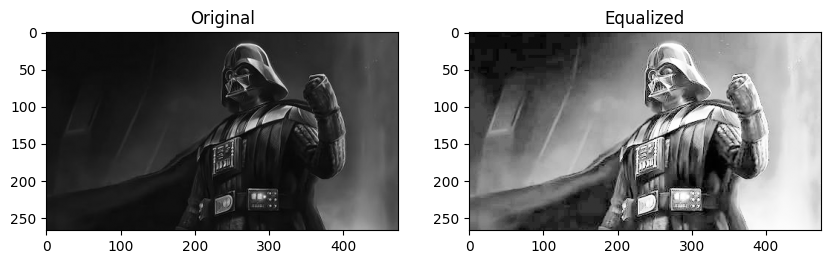

/tmp/ipykernel_1253/3967569733.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.ravel(), 256, [0,256])
/tmp/ipykernel_1253/3967569733.py:33: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0,256])


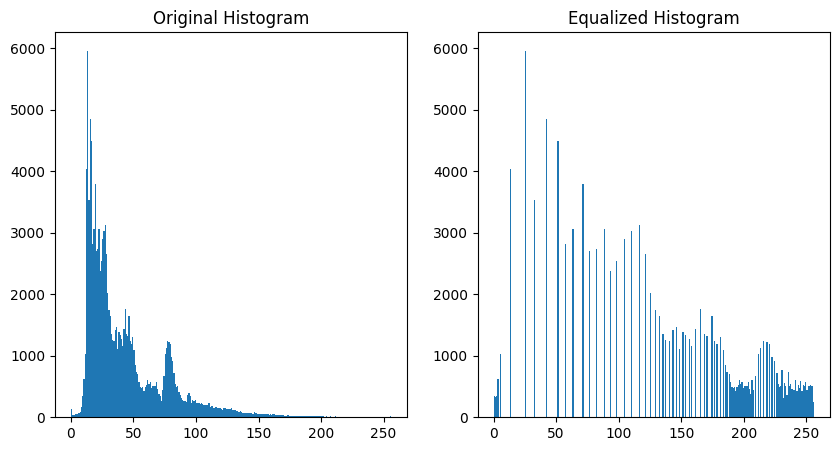

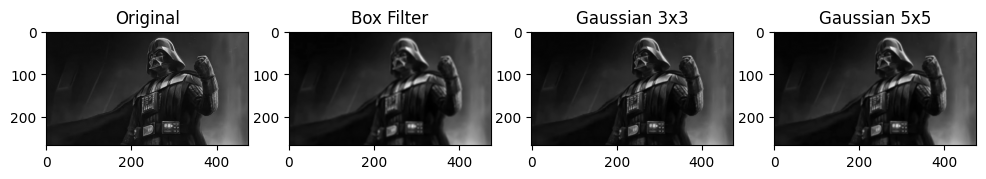

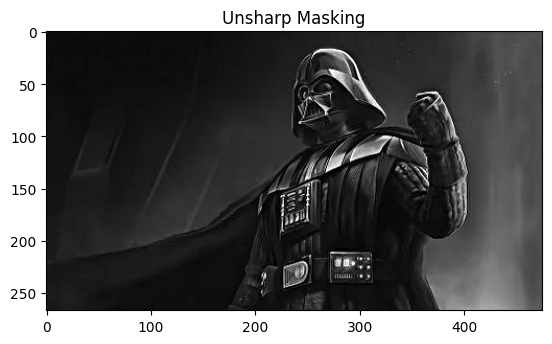

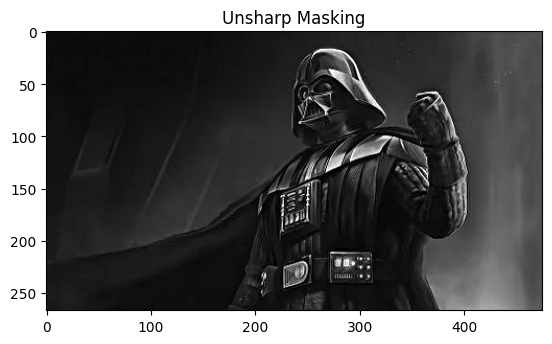

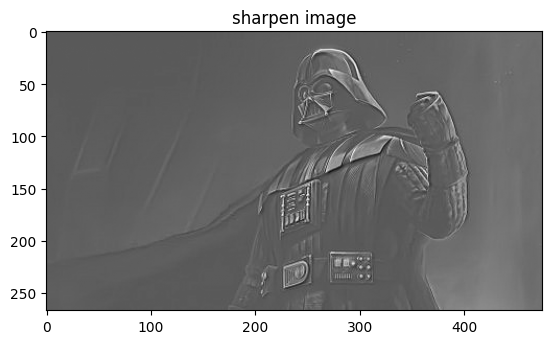

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

image = cv2.imread('fruit basket.jpg', cv2.IMREAD_GRAYSCALE)

# Add a check to see if the image was loaded successfully
if image is None:
    print("Error: Could not load image 'fruit basket.jpg'. Please ensure the file exists and is in the correct path.")
else:
    equalized = cv2.equalizeHist(image)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(image, cmap='gray')
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(equalized, cmap='gray')
    plt.title("Equalized")

    plt.show()

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.hist(image.ravel(), 256, [0,256])
    plt.title("Original Histogram")

    plt.subplot(1,2,2)
    plt.hist(equalized.ravel(), 256, [0,256])
    plt.title("Equalized Histogram")

    plt.show()

    gaussian_3 = cv2.GaussianBlur(image, (3, 3), 0)
    gaussian_5 = cv2.GaussianBlur(image, (5, 5), 0)

    def box_filt(n):
        if n <= 0 or n % 2 == 0:
            raise ValueError("Window size must be a positive odd integer.")
        kernel = np.ones((n, n), np.float32) / (n * n)
        return kernel

    def apply_filters(image_input, box, filt_size):
        pad_size = int(np.ceil(filt_size/2))

        image_padded = np.pad(image_input,
                              pad_width=((pad_size,pad_size),
                                         (pad_size,pad_size)),
                              mode='symmetric')

        image_box = copy.deepcopy(image_input)
        row, column = image_input.shape

        for i in range(row):
            for j in range(column):
                patch_curr = image_padded[i:i + filt_size,
                                          j:j + filt_size]
                results_box = box * patch_curr
                image_box[i,j] = np.sum(results_box)

        return image_box

    box_kernel = box_filt(5)
    box_filtered = apply_filters(image, box_kernel, 5)

    plt.figure(figsize=(12,6))

    plt.subplot(1,4,1)
    plt.imshow(image, cmap='gray')
    plt.title("Original")

    plt.subplot(1,4,2)
    plt.imshow(box_filtered, cmap='gray')
    plt.title("Box Filter")

    plt.subplot(1,4,3)
    plt.imshow(gaussian_3, cmap='gray')
    plt.title("Gaussian 3x3")

    plt.subplot(1,4,4)
    plt.imshow(gaussian_5, cmap='gray')
    plt.title("Gaussian 5x5")

    plt.show()


    blurred = cv2.GaussianBlur(image, (9, 9), 10)

    unsharp_image = cv2.addWeighted(image, 1.5,
                                    blurred, -0.5, 0)

    plt.imshow(unsharp_image, cmap='gray')
    plt.title('Unsharp Masking')
    plt.show()


    blurred = cv2.GaussianBlur(image, (9, 9), 10)

    unsharp_image = cv2.addWeighted(image, 1.5,
                                    blurred, -0.5, 0)

    plt.imshow(unsharp_image, cmap='gray')
    plt.title('Unsharp Masking')
    plt.show()

    filt_size = 5
    k = 2

    # The original image_input was loading the image again, and converting to float32/255.
    # To avoid repeating cv2.imread and potential issues with the previous 'image' variable,
    # I will reuse the 'image' variable and convert it if necessary for this section.
    # Assuming 'image' is already grayscale (cv2.IMREAD_GRAYSCALE), convert it to float32 and normalize.
    image_input_float = image.astype('float32') / 255

    box = box_filt(filt_size)

    image_blur = apply_filters(image_input_float, box, filt_size)
    image_diff = image_input_float - image_blur
    image_sharp = image_input_float + k*image_diff

    plt.imshow(image_sharp, cmap='gray')
    plt.title('sharpen image')
    plt.show()

Report on Image Processing Tasks
Task 1: Histogram Equalization
Objective:
Improve the contrast of the grayscale image fruit basket.jpg using histogram equalization.
Procedure:
The image is loaded in grayscale using OpenCV.
cv2.equalizeHist() is applied to enhance the contrast.
Both the original and equalized images are displayed side by side.
Histograms of the original and equalized images are plotted to visualize changes in pixel intensity distribution.
Observations:
The original histogram was concentrated in a narrow intensity range, indicating low contrast.
After equalization, the histogram spreads more evenly across all intensity levels.
Visually, the equalized image appears brighter and more detailed in shadow and highlight regions.
Conclusion:
Histogram equalization is effective in improving the contrast of grayscale images, making features more distinguishable.
Task 2: Smoothing/Blurring
Objective:
Reduce noise in the image using different smoothing filters.
Filters Used:
Box Filter (5x5) – A simple averaging filter implemented manually.
Gaussian Filter (3x3 & 5x5) – A weighted averaging filter that reduces noise while preserving edges better than a box filter.
Procedure:
A 5x5 box filter is created using a kernel of ones divided by 25.
A custom function apply_filters() is used to convolve the image with the box kernel.
Gaussian blurring is applied with OpenCV using kernel sizes 3x3 and 5x5.
Results are displayed side by side for comparison.
Observations:
Box filtering produces a uniformly blurred image, but edges appear softer.
Gaussian filtering provides smoother blurring with better edge preservation, especially with smaller kernels.
Increasing the kernel size (5x5 vs 3x3) increases the blur effect.
Conclusion:
Gaussian filters are generally preferred over box filters for noise reduction due to their edge-preserving properties.
Task 3: Image Sharpening (Unsharp Masking)
Objective:
Enhance fine details in the image using unsharp masking.
Procedure:
Gaussian blur is applied to the original image with a large kernel (9x9) and high sigma (10).
The blurred image is subtracted from the original (weighted sum) to enhance high-frequency components.
The unsharp mask is applied using cv2.addWeighted() to generate a sharpened image.
An alternative manual sharpening method using box-filtered blur and a scaling factor k=2 is also implemented.
Observations:
Unsharp masking increases edge contrast, making textures and object boundaries more distinct.
Both OpenCV and manual sharpening methods produced similar enhancements.
Care must be taken with high sharpening factors, as this may introduce noise amplification.
Conclusion:
Unsharp masking is an effective technique to enhance fine details and edges in grayscale images without significantly altering overall brightness.